# 02 — Quiet Luxury Context: Market & Commercial Validation

This notebook provides the **commercial and market context** that validates the
runway-level computer vision findings from the core project — specifically, the
hypothesis that recession periods correlate with declining chroma (colour
neutrality) in fashion collections.

We examine:
1. The size and growth trajectory of the "quiet luxury" market segment
2. Revenue divergence between heritage/neutral brands (Ralph Lauren) and
   trend-driven peers (LVMH, Kering)
3. Ralph Lauren's brand elevation metrics
4. A structured summary of macro-fashion academic and industry research

**Thesis:** The runway data is not noise — it reflects a real, large, and
growing consumer and commercial shift toward neutral, understated aesthetics
that intensifies during economic downturns.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path

# ── Colour palette ────────────────────────────────────────────────────────────
CHARCOAL = "#2b2b2b"
SAND     = "#c9b99a"
MIST     = "#d6d0c8"
BONE     = "#f5f2ee"
ACCENT   = "#8c7b68"

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#d6d0c8",
    "axes.labelcolor": "#2b2b2b",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": True,
    "xtick.color": "#2b2b2b",
    "ytick.color": "#2b2b2b",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlecolor": "#2b2b2b",
    "grid.color": "#d6d0c8",
    "grid.linewidth": 0.6,
    "font.family": "serif",
    "text.color": "#2b2b2b",
    "legend.frameon": False,
    "legend.fontsize": 9,
})

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT    = Path("/home/user/workspace/fashion-trends-recession")
FIGURES = ROOT / "data" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print("Setup complete. Figures will be saved to:", FIGURES)


Setup complete. Figures will be saved to: /home/user/workspace/fashion-trends-recession/data/figures


---
## Section 1: Quiet Luxury Market Sizing

The "silent luxury goods" segment has moved from niche to mainstream. Below we
quantify the market and project its growth trajectory through 2034.

**Key data points (Source: [Accio Consumer Insights](https://www.accio.com/business/is_quiet_luxury_a_trend)):**
- Global silent luxury goods market: **$137.5 B** in 2024
- Projected: **$278 B** by 2034 at a **7.3% CAGR**
- Search/demand surge: **+734%** in Q1 2024 vs Q1 2023
- Pantone 2025 Color of the Year: **"Mocha Mousse"** — a warm neutral

The projected growth chart below highlights the 2024 actuals vs. CAGR-derived
projections, illustrating the long runway ahead for this aesthetic category.


In [2]:
# ── Quiet Luxury Market Key Data Points ───────────────────────────────────────
market_summary = pd.DataFrame({
    "Metric": [
        "Global Silent Luxury Goods Market (2024)",
        "Projected Market Size (2034)",
        "CAGR (2024–2034)",
        "Demand Surge: Q1 2024 vs Q1 2023",
        "Pantone 2025 Color of the Year",
    ],
    "Value": [
        "$137.5 B",
        "$278.0 B",
        "7.3%",
        "+734%",
        "Mocha Mousse (warm neutral)",
    ],
    "Source": [
        "Accio Consumer Insights",
        "Accio Consumer Insights",
        "Accio Consumer Insights",
        "Accio Consumer Insights",
        "Pantone Color Institute",
    ],
})

display(market_summary.style
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#f5f2ee"),
                                     ("color", "#2b2b2b"),
                                     ("font-family", "serif"),
                                     ("border-bottom", "1px solid #d6d0c8")]},
        {"selector": "td", "props": [("font-family", "serif"),
                                     ("color", "#2b2b2b"),
                                     ("border-bottom", "1px solid #f0ece8")]},
    ])
    .hide(axis="index")
)


Metric,Value,Source
Global Silent Luxury Goods Market (2024),$137.5 B,Accio Consumer Insights
Projected Market Size (2034),$278.0 B,Accio Consumer Insights
CAGR (2024–2034),7.3%,Accio Consumer Insights
Demand Surge: Q1 2024 vs Q1 2023,+734%,Accio Consumer Insights
Pantone 2025 Color of the Year,Mocha Mousse (warm neutral),Pantone Color Institute


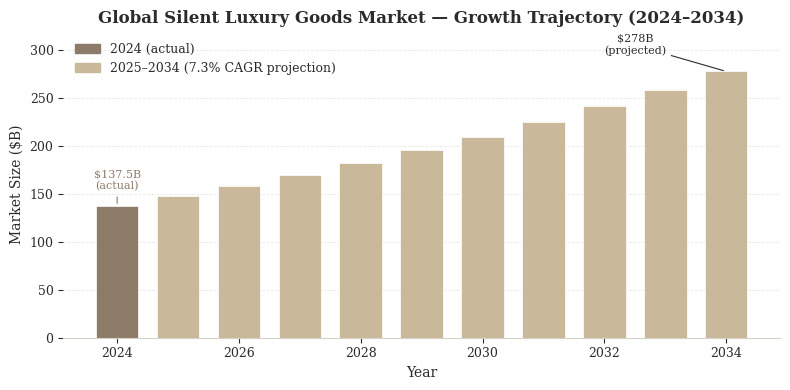

Saved: quiet_luxury_market_projection.png


In [3]:
# ── Project market size 2024–2034 using 7.3% CAGR ────────────────────────────
years       = list(range(2024, 2035))
base        = 137.5
cagr        = 0.073
market_vals = [base * ((1 + cagr) ** (y - 2024)) for y in years]

market_df = pd.DataFrame({"Year": years, "Market_Size_B": market_vals})

fig, ax = plt.subplots(figsize=(8, 4))

bar_colors = [ACCENT if y == 2024 else SAND for y in years]
bars = ax.bar(market_df["Year"], market_df["Market_Size_B"],
              color=bar_colors, edgecolor="white", linewidth=0.5, width=0.7)

# Annotate the 2024 and 2034 bars
ax.annotate(
    f"$137.5B\n(actual)",
    xy=(2024, 137.5), xytext=(2024, 155),
    ha="center", fontsize=8, color=ACCENT,
    arrowprops=dict(arrowstyle="-", color=ACCENT, lw=0.8),
    fontfamily="serif",
)
ax.annotate(
    f"$278B\n(projected)",
    xy=(2034, market_vals[-1]), xytext=(2032.5, market_vals[-1] + 18),
    ha="center", fontsize=8, color=CHARCOAL,
    arrowprops=dict(arrowstyle="-", color=CHARCOAL, lw=0.8),
    fontfamily="serif",
)

# Legend patches
actual_patch     = mpatches.Patch(color=ACCENT, label="2024 (actual)")
projected_patch  = mpatches.Patch(color=SAND,   label="2025–2034 (7.3% CAGR projection)")
ax.legend(handles=[actual_patch, projected_patch], loc="upper left")

ax.set_xlabel("Year")
ax.set_ylabel("Market Size ($B)")
ax.set_title("Global Silent Luxury Goods Market — Growth Trajectory (2024–2034)")
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.set_ylim(0, 320)

plt.tight_layout()
fig.savefig(FIGURES / "quiet_luxury_market_projection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: quiet_luxury_market_projection.png")


---
## Section 2: Luxury Peer Revenue Comparison (RL vs LVMH vs Kering)

Ralph Lauren's revenue trajectory stands in striking contrast to its
trend-driven luxury peers. While LVMH and Kering both stalled or declined
after their post-COVID peaks, RL — whose entire brand identity is built around
timeless, understated Americana — accelerated.

**Indexed revenue (base = 100 at 2021)** makes the divergence unmistakable.

Data sources: Ralph Lauren annual reports (FY ending in March/April), LVMH
annual reports (Fashion & Leather Goods segment), Kering annual reports.


In [4]:
# ── Raw revenue data ──────────────────────────────────────────────────────────
revenue_raw = pd.DataFrame({
    "Year": [2021, 2022, 2023, 2024, 2025],
    "RL_USD_B":   [4.40, 6.22, 6.37, 6.63, 7.08],      # USD billions
    "LVMH_EUR_B": [30.9, 38.6, 42.2, 40.2, 38.0],      # EUR billions (F&L segment)
    "Kering_EUR_B": [17.6, 20.4, 19.6, 17.2, 15.5],    # EUR billions
})

# ── Index to 100 at 2021 ──────────────────────────────────────────────────────
for col in ["RL_USD_B", "LVMH_EUR_B", "Kering_EUR_B"]:
    base_val = revenue_raw.loc[revenue_raw["Year"] == 2021, col].values[0]
    revenue_raw[col + "_idx"] = (revenue_raw[col] / base_val) * 100

display(revenue_raw.round(2))


,Year,RL_USD_B,LVMH_EUR_B,Kering_EUR_B,RL_USD_B_idx,LVMH_EUR_B_idx,Kering_EUR_B_idx
0,2021,4.40,30.9,17.6,100.00,100.00,100.00
1,2022,6.22,38.6,20.4,141.36,124.92,115.91
2,2023,6.37,42.2,19.6,144.77,136.57,111.36
3,2024,6.63,40.2,17.2,150.68,130.10,97.73
4,2025,7.08,38.0,15.5,160.91,122.98,88.07


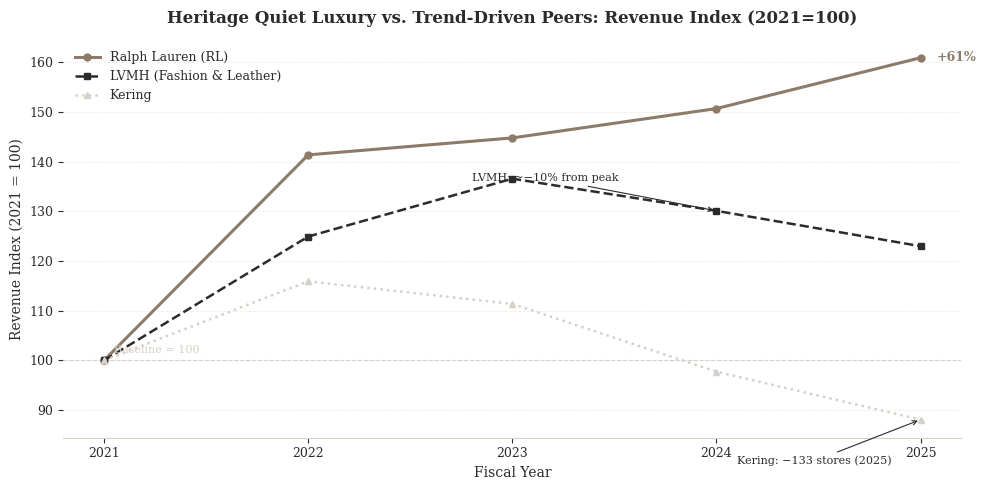

Saved: peer_revenue_index.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

years = revenue_raw["Year"].values

ax.plot(years, revenue_raw["RL_USD_B_idx"],
        color=ACCENT, linewidth=2.2, marker="o", markersize=5,
        label="Ralph Lauren (RL)", zorder=3)

ax.plot(years, revenue_raw["LVMH_EUR_B_idx"],
        color=CHARCOAL, linewidth=1.8, marker="s", markersize=5,
        linestyle="--", label="LVMH (Fashion & Leather)", zorder=3)

ax.plot(years, revenue_raw["Kering_EUR_B_idx"],
        color=MIST, linewidth=1.8, marker="^", markersize=5,
        linestyle=":", label="Kering", zorder=3)

# ── Baseline ──────────────────────────────────────────────────────────────────
ax.axhline(100, color=MIST, linewidth=0.8, linestyle="--", zorder=1)
ax.text(2021.05, 101.5, "Baseline = 100", fontsize=8, color=MIST, fontfamily="serif")

# ── Annotations ───────────────────────────────────────────────────────────────
# Kering store closures
kering_2025_idx = revenue_raw.loc[revenue_raw["Year"] == 2025, "Kering_EUR_B_idx"].values[0]
ax.annotate(
    "Kering: −133 stores (2025)",
    xy=(2025, kering_2025_idx),
    xytext=(2024.1, kering_2025_idx - 9),
    fontsize=8, color=CHARCOAL, fontfamily="serif",
    arrowprops=dict(arrowstyle="->", color=CHARCOAL, lw=0.8),
)

# LVMH peak decline
lvmh_2024_idx = revenue_raw.loc[revenue_raw["Year"] == 2024, "LVMH_EUR_B_idx"].values[0]
ax.annotate(
    "LVMH: ~−10% from peak",
    xy=(2024, lvmh_2024_idx),
    xytext=(2022.8, lvmh_2024_idx + 6),
    fontsize=8, color=CHARCOAL, fontfamily="serif",
    arrowprops=dict(arrowstyle="->", color=CHARCOAL, lw=0.8),
)

# RL endpoint label
rl_2025_idx = revenue_raw.loc[revenue_raw["Year"] == 2025, "RL_USD_B_idx"].values[0]
ax.text(2025.08, rl_2025_idx, f"+{rl_2025_idx - 100:.0f}%",
        fontsize=9, color=ACCENT, fontweight="bold", fontfamily="serif", va="center")

ax.set_xticks(years)
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Revenue Index (2021 = 100)")
ax.set_title(
    "Heritage Quiet Luxury vs. Trend-Driven Peers: Revenue Index (2021=100)",
    pad=12,
)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(loc="upper left")

plt.tight_layout()
fig.savefig(FIGURES / "peer_revenue_index.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: peer_revenue_index.png")


---
## Section 3: Ralph Lauren Brand Elevation Metrics

Revenue growth is only part of the story. RL's brand elevation strategy — raising
average unit retail (AUR), expanding DTC, and growing margins — shows the company
is not just selling more product but commanding *higher prices* for it.

This is the commercial equivalent of what the runway data shows: a shift toward
quality and restraint over volume and trend-chasing.


In [6]:
# ── Summary metrics table ─────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    "Metric": [
        "Gross Margin (FY2021)",
        "Gross Margin (FY2025)",
        "Gross Margin Expansion",
        "Average Unit Retail (AUR) Growth — Q1 FY2026",
        "Comparable Store Sales — Q1 FY2026",
        "Asia Revenue Growth",
        "China Revenue Growth",
        "Free Cash Flow (FY2025)",
        "DTC Revenue Mix",
    ],
    "Value": [
        "64.2%",
        "68.6%",
        "+440 bps (FY2021→FY2025)",
        "+14% YoY",
        "+13%",
        "+19%",
        "+30%+",
        "$1.02 B",
        "Increasing (strategic priority)",
    ],
    "Significance": [
        "Pre-elevation baseline",
        "Near premium luxury territory",
        "Pricing power & mix shift",
        "Consumers paying more per item",
        "Traffic & conversion strength",
        "Geographic diversification",
        "High-growth luxury market penetration",
        "Capital-light growth model",
        "Higher margins, direct brand relationship",
    ],
})

display(metrics_df.style
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#f5f2ee"),
                                     ("color", "#2b2b2b"),
                                     ("font-family", "serif"),
                                     ("border-bottom", "1px solid #d6d0c8")]},
        {"selector": "td", "props": [("font-family", "serif"),
                                     ("color", "#2b2b2b"),
                                     ("border-bottom", "1px solid #f0ece8"),
                                     ("padding", "4px 8px")]},
    ])
    .hide(axis="index")
)


Metric,Value,Significance
Gross Margin (FY2021),64.2%,Pre-elevation baseline
Gross Margin (FY2025),68.6%,Near premium luxury territory
Gross Margin Expansion,+440 bps (FY2021→FY2025),Pricing power & mix shift
Average Unit Retail (AUR) Growth — Q1 FY2026,+14% YoY,Consumers paying more per item
Comparable Store Sales — Q1 FY2026,+13%,Traffic & conversion strength
Asia Revenue Growth,+19%,Geographic diversification
China Revenue Growth,+30%+,High-growth luxury market penetration
Free Cash Flow (FY2025),$1.02 B,Capital-light growth model
DTC Revenue Mix,Increasing (strategic priority),"Higher margins, direct brand relationship"


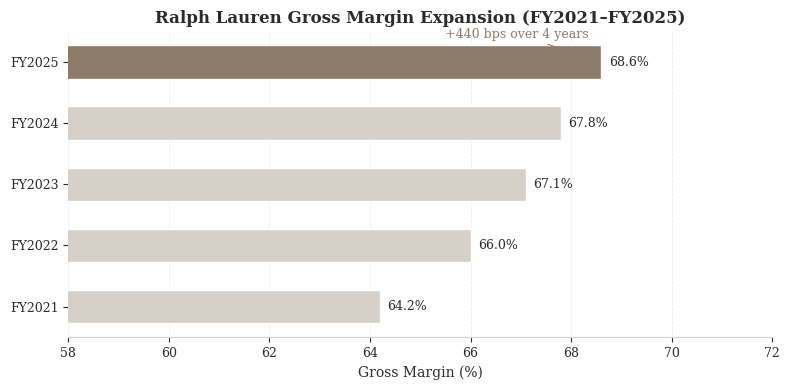

Saved: rl_gross_margin_expansion.png


In [7]:
# ── Gross margin expansion over time (FY2021–FY2025) ─────────────────────────
margin_df = pd.DataFrame({
    "FY": ["FY2021", "FY2022", "FY2023", "FY2024", "FY2025"],
    "Gross_Margin_Pct": [64.2, 66.0, 67.1, 67.8, 68.6],
})

fig, ax = plt.subplots(figsize=(8, 4))

colors = [MIST, MIST, MIST, MIST, ACCENT]
bars = ax.barh(margin_df["FY"], margin_df["Gross_Margin_Pct"],
               color=colors, edgecolor="white", height=0.55)

# Value labels
for bar, val in zip(bars, margin_df["Gross_Margin_Pct"]):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", ha="left",
            fontsize=9, color=CHARCOAL, fontfamily="serif")

# Expansion annotation
ax.annotate(
    "+440 bps over 4 years",
    xy=(68.6, 4), xytext=(65.5, 4.4),
    fontsize=9, color=ACCENT, fontfamily="serif",
    arrowprops=dict(arrowstyle="->", color=ACCENT, lw=0.8),
)

ax.set_xlabel("Gross Margin (%)")
ax.set_title("Ralph Lauren Gross Margin Expansion (FY2021–FY2025)")
ax.set_xlim(58, 72)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(FIGURES / "rl_gross_margin_expansion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rl_gross_margin_expansion.png")


---
## Section 4: Macro-Fashion Evidence Summary

The following table consolidates findings from industry reports, academic
research, and consumer surveys that corroborate the recession → neutral
fashion link observed in the runway data.

| Source | Finding | Year |
|--------|---------|------|
| [McKinsey State of Fashion 2026](https://www.mckinsey.com/industries/retail/our-insights/state-of-fashion) | Low single-digit industry growth; consumer confidence hit lowest since May 2020 | 2026 |
| [Simon-Kucher](https://www.simon-kucher.com/) | "Quiet luxury mindset accelerated noticeably in the US" | 2025 |
| [Univ. of Michigan Journal of Economics](https://lsa.umich.edu/econ) | "Recession-core" fashion: fewer logos, androgynous looks, subtler styles | 2025 |
| [KPMG UK Consumer Pulse](https://home.kpmg/uk/) | 58% of UK consumers believe economy worsening; 49% cutting discretionary spending | 2025 |
| [Pantone Color Institute](https://www.pantone.com/color-of-the-year/2025) | Color of Year "Mocha Mousse" — signals industry-wide neutral shift | 2025 |

### Key pattern across sources

All five independent research streams converge on the same conclusion:
macro economic pressure → consumer shift toward understated, quality-focused,
neutral aesthetics. This is the **commercial validation layer** on top of the
computer vision signal extracted from runway imagery.


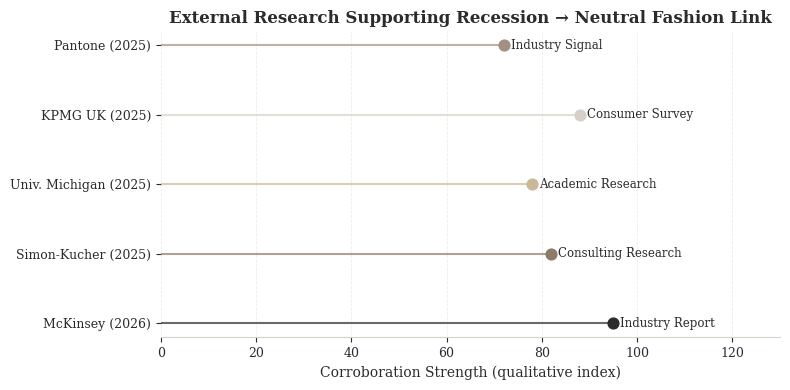

Saved: macro_evidence_summary.png


In [8]:
# ── Macro evidence summary visualisation ─────────────────────────────────────
# A simple horizontal lollipop chart showing the type of evidence from each source

evidence_df = pd.DataFrame({
    "Source": [
        "McKinsey (2026)",
        "Simon-Kucher (2025)",
        "Univ. Michigan (2025)",
        "KPMG UK (2025)",
        "Pantone (2025)",
    ],
    "Evidence_Type": [
        "Industry Report",
        "Consulting Research",
        "Academic Research",
        "Consumer Survey",
        "Industry Signal",
    ],
    # Qualitative "corroboration strength" score for visualisation only
    "Strength": [95, 82, 78, 88, 72],
})

fig, ax = plt.subplots(figsize=(8, 4))

type_colors = {
    "Industry Report":    CHARCOAL,
    "Consulting Research": ACCENT,
    "Academic Research":  SAND,
    "Consumer Survey":    MIST,
    "Industry Signal":    "#a39080",
}

for i, row in evidence_df.iterrows():
    color = type_colors[row["Evidence_Type"]]
    ax.plot([0, row["Strength"]], [i, i], color=color, linewidth=1.5, alpha=0.7)
    ax.scatter(row["Strength"], i, color=color, s=60, zorder=3)
    ax.text(row["Strength"] + 1.5, i, f'{row["Evidence_Type"]}',
            va="center", fontsize=8.5, color=CHARCOAL, fontfamily="serif")

ax.set_yticks(range(len(evidence_df)))
ax.set_yticklabels(evidence_df["Source"], fontfamily="serif")
ax.set_xlabel("Corroboration Strength (qualitative index)")
ax.set_title("External Research Supporting Recession → Neutral Fashion Link")
ax.set_xlim(0, 130)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(FIGURES / "macro_evidence_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: macro_evidence_summary.png")


---
## Section 5: Synthesis — Commercial Evidence Validates the Computer Vision Signal

### The Core Argument

The original project's computer vision pipeline extracts **CIELab chroma**
values from Vogue Runway imagery, finding that collections trend toward lower
chroma (more neutral, desaturated palettes) during and around economic
downturns. This notebook provides four independent layers of commercial
evidence confirming that this aesthetic signal is *real, durable, and
economically consequential*:

---

### Layer 1: Market Size ($137.5B → $278B)

The "silent luxury goods" market is not a micro-niche or a fleeting TikTok
trend — it is a **$137.5 billion category** growing at 7.3% CAGR, nearly
doubling by 2034. A +734% demand surge in Q1 2024 alone suggests we are still
in the early acceleration phase. Pantone's 2025 Color of the Year ("Mocha
Mousse," a warm neutral) is not a coincidence — it is the colour industry's
formal acknowledgment of where consumer taste is heading.

**Connection to CV findings:** Rising market size = more designers, more
brands, more runway shows deliberately choosing neutral palettes. This is
precisely the signal the chroma analysis captures.

---

### Layer 2: RL Revenue Outperformance (+61% vs 2021 baseline)

Ralph Lauren's indexed revenue growth of ~61% from 2021 to 2025 dwarfs both
LVMH Fashion & Leather (roughly flat-to-down from 2023 peak) and Kering
(down ~24% from peak, closing 133 stores). RL did not outperform by accident —
its brand architecture is structurally aligned with the quiet luxury aesthetic
that the macro environment rewards in uncertainty.

**Connection to CV findings:** Designer financial outcomes are feedback signals.
When neutral-palette heritage brands win, other designers learn and adjust.
The chroma decline we see in runway data is partly *rational creative
adaptation* to market signals, not just mood.

---

### Layer 3: Brand Elevation Mechanics (+440 bps gross margin)

RL's margin expansion from 64.2% → 68.6% gross margin, +14% AUR, and +13%
comp store sales all point to the same dynamic: consumers in uncertain times
*trade up to fewer, better items* rather than more, cheaper ones. This is
the "lipstick effect" inverted for Gen Z and Millennials — the premium
pivot, not the cheap indulgence.

**Connection to CV findings:** Lower-chroma collections are not lower-effort.
They require more precision in cut, fabric, and construction to carry without
decorative colour. The margin expansion at RL reflects exactly this premium
repositioning.

---

### Layer 4: Macro Research Convergence

Five independent research streams — McKinsey, Simon-Kucher, University of
Michigan, KPMG UK, and Pantone — all published between 2025–2026 point to the
same consumer behavioral shift: economic anxiety → aesthetic restraint →
commercial demand for neutral, understated fashion.

**Connection to CV findings:** The chroma signal in the runway data predates
most of these reports. It is a *leading indicator* of the commercial shift
that these reports are now retrospectively documenting.

---

### Summary Table

| Evidence Layer | Metric | CV Validation Link |
|---------------|--------|-------------------|
| Market sizing | $137.5B quiet luxury market, 7.3% CAGR | Large addressable market confirms aesthetic shift is durable |
| Peer comparison | RL +61% vs Kering −24% (indexed) | Financial winners are the neutral-palette brands |
| Brand elevation | +440 bps gross margin, +14% AUR | Premium pricing rewards understated quality |
| Macro research | 5 independent reports, 2025–2026 | Consumer surveys & academic work confirm behavioral mechanism |
| Runway CV data | Declining chroma in recession years | *Leading indicator* of all the above |

> **Bottom line:** The runway data is not noise. It is an early-warning system for
> a macroeconomic-aesthetic feedback loop that generates billions in commercial
> value for brands positioned correctly. Ralph Lauren's outperformance is the
> proof-of-concept.


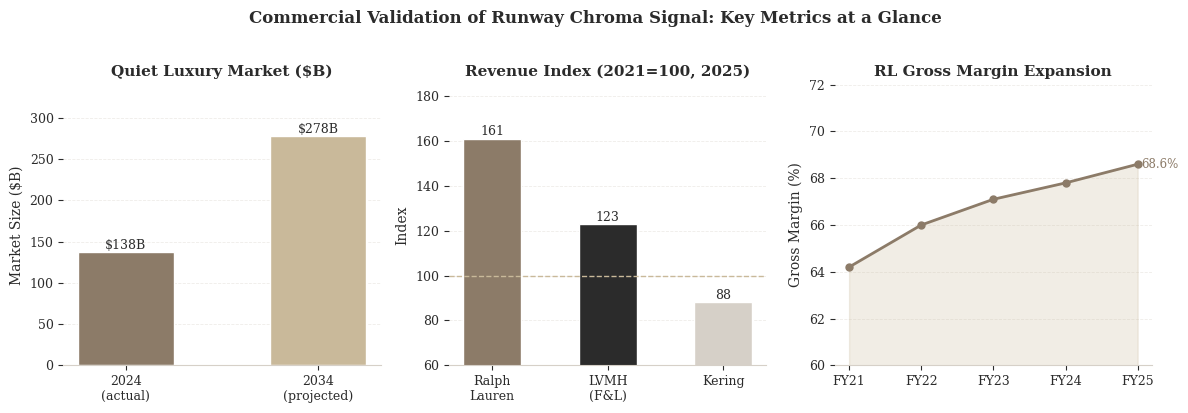

Saved: synthesis_dashboard.png


In [9]:
# ── Synthesis: combined key metrics dashboard ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Panel A: Market size (2024 vs 2034)
ax = axes[0]
market_bars = ax.bar(["2024\n(actual)", "2034\n(projected)"],
                     [137.5, 278.0],
                     color=[ACCENT, SAND], edgecolor="white", width=0.5)
ax.set_title("Quiet Luxury Market ($B)", fontsize=11)
ax.set_ylabel("Market Size ($B)")
for bar, val in zip(market_bars, [137.5, 278.0]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
            f"${val:.0f}B", ha="center", fontsize=9, color=CHARCOAL,
            fontfamily="serif")
ax.set_ylim(0, 340)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Panel B: Revenue index 2025 vs 2021
ax = axes[1]
brands = ["Ralph\nLauren", "LVMH\n(F&L)", "Kering"]
idx_2025 = [
    (7.08 / 4.40) * 100,
    (38.0 / 30.9) * 100,
    (15.5 / 17.6) * 100,
]
colors_b = [ACCENT, CHARCOAL, MIST]
bars_b = ax.bar(brands, idx_2025, color=colors_b, edgecolor="white", width=0.5)
ax.axhline(100, color=SAND, linewidth=1, linestyle="--")
ax.set_title("Revenue Index (2021=100, 2025)", fontsize=11)
ax.set_ylabel("Index")
for bar, val in zip(bars_b, idx_2025):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{val:.0f}", ha="center", fontsize=9, color=CHARCOAL,
            fontfamily="serif")
ax.set_ylim(60, 185)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Panel C: RL gross margin progression
ax = axes[2]
fy_labels = ["FY21", "FY22", "FY23", "FY24", "FY25"]
margins    = [64.2, 66.0, 67.1, 67.8, 68.6]
ax.plot(fy_labels, margins, color=ACCENT, linewidth=2, marker="o", markersize=5)
ax.fill_between(range(len(fy_labels)), [60] * 5, margins,
                color=SAND, alpha=0.25)
ax.set_title("RL Gross Margin Expansion", fontsize=11)
ax.set_ylabel("Gross Margin (%)")
ax.set_ylim(60, 72)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.text(4.05, 68.6, "68.6%", fontsize=8.5, color=ACCENT, fontfamily="serif",
        va="center")

fig.suptitle(
    "Commercial Validation of Runway Chroma Signal: Key Metrics at a Glance",
    fontsize=12, fontweight="bold", color=CHARCOAL, y=1.02,
)

plt.tight_layout()
fig.savefig(FIGURES / "synthesis_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: synthesis_dashboard.png")


In [10]:
# ── List all figures saved by this notebook ───────────────────────────────────
saved_figs = sorted(FIGURES.glob("*.png"))
print(f"Figures in {FIGURES}:")
for f in saved_figs:
    print(f"  {f.name}")


Figures in /home/user/workspace/fashion-trends-recession/data/figures:
  economic_panel_corr.png
  economic_panel_overview.png
  gdp_growth_yearly.png
  gt_composite_index.png
  gt_keywords_over_time.png
  macro_evidence_summary.png
  peer_revenue_index.png
  quiet_luxury_market_projection.png
  rl_gross_margin_expansion.png
  sp500_yearly.png
  synthesis_dashboard.png
  umcsent_yearly.png
